In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")

print("Path to dataset files:", path)

100%|██████████| 286k/286k [00:00<00:00, 54.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/lakshmi25npathi/bike-sharing-dataset/versions/1


In [3]:
data = pd.read_csv(f'{path}/hour.csv')

# Select features and target
features = ['temp', 'atemp', 'hum', 'windspeed', 'hr', 'weekday', 'season']
target = 'cnt'
X = data[features].values
y = data[target].values

# Normalize features and target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

In [4]:
# Prepare sequences (use past 24 hours to predict next hour)
def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X_scaled[i:i + seq_length])
        ys.append(y_scaled[i + seq_length])
    return np.array(Xs), np.array(ys)

seq_length = 24  # 24-hour sequences
X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)

# Split into training and testing (80% train, 20% test)
train_size = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:train_size], X_seq[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]

In [5]:
# Build LSTM model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_length, len(features)), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,545 (80.25 KB)

 Trainable params: 20,545 (80.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0202 - val_loss: 0.0338
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0123 - val_loss: 0.0219
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0084 - val_loss: 0.0182
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0068 - val_loss: 0.0123
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0060 - val_loss: 0.0116
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0055 - val_loss: 0.0149
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.0050 - val_loss: 0.0128
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0050 - val_loss: 0.0176
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0046 - val_loss: 0.0135
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0045 - val_loss: 0.0233
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0043 - val_loss: 0.0162
Epoch 12/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 

In [8]:
# Evaluate on test set
loss = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}')

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0216
Test Loss: 0.01959211565554142


In [9]:
# Make predictions
predictions = model.predict(X_test)

# Inverse transform predictions and actual values
predictions = scaler_y.inverse_transform(predictions)
y_test_inv = scaler_y.inverse_transform(y_test)

# Calculate RMSE
rmse = np.sqrt(np.mean((predictions - y_test_inv) ** 2))
print(f'Test RMSE: {rmse}')

109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
Test RMSE: 136.61251479917337


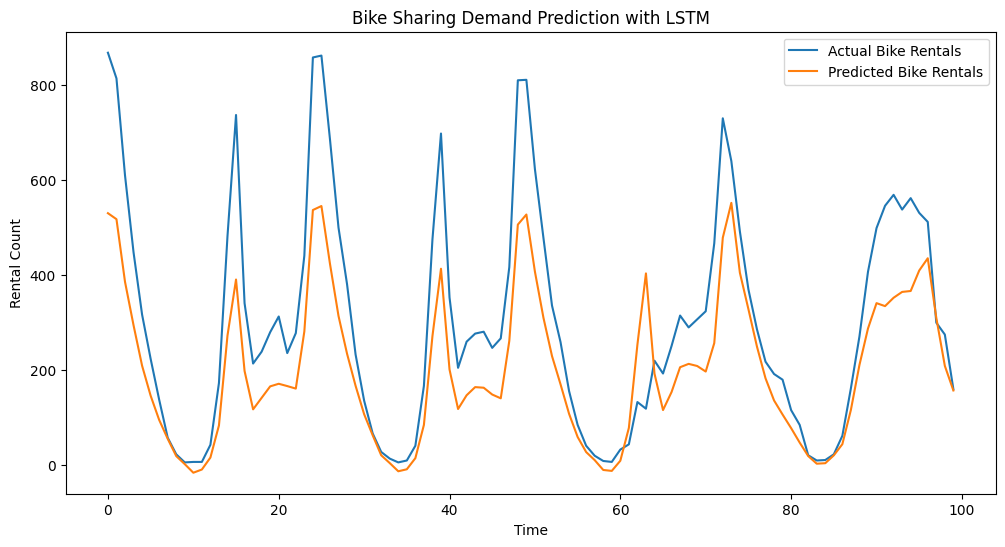

In [11]:
# Plot results (sample of 100 points for clarity)
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv[:100], label='Actual Bike Rentals')
plt.plot(predictions[:100], label='Predicted Bike Rentals')
plt.title('Bike Sharing Demand Prediction with LSTM')
plt.xlabel('Time')
plt.ylabel('Rental Count')
plt.legend()
plt.show()